 ## 1. Preparação do Ambiente
 Nesta etapa, importamos as bibliotecas essenciais para o pipeline de Ciência de Dados:
 * **Pandas/Numpy**: Manipulação de dados e álgebra linear.
 * **Matplotlib/Seaborn**: Visualização de dados.
 * **Scikit-Learn**: Ferramentas de pré-processamento (imputação, encoding, escalonamento).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


 ## 2. Geração do Dataset Sintético
 Criamos um conjunto de dados que simula a realidade da saúde pública em Alagoas.
 O dataset inclui variáveis categóricas (município, região), numéricas (idade, renda) e
 introduz propositalmente **valores ausentes (NaN)** para que possamos tratar posteriormente.

In [2]:
np.random.seed(42)
n = 200

data = {
    'municipio': np.random.choice(
        ['Maceió', 'Arapiraca', 'Palmeira dos Índios', 'União dos Palmares',
         'Penedo', 'Delmiro Gouveia', 'São Miguel dos Campos', 'Coruripe'],
        size=n
    ),
    'regiao': np.random.choice(['Leste', 'Agreste', 'Sertão'], size=n, p=[0.4, 0.35, 0.25]),
    'nivel_atencao': np.random.choice(
        ['Básica', 'Média Complexidade', 'Alta Complexidade'], size=n
    ),
    'idade_paciente': np.random.normal(45, 15, n).clip(0, 100),
    'renda_per_capita': np.random.exponential(scale=1200, size=n),
    'distancia_hospital_km': np.random.exponential(scale=30, size=n),
    'internacoes_ano': np.random.poisson(lam=3, size=n),
    'dias_internacao': np.random.exponential(scale=5, size=n).clip(1, 60),
    'obito': np.random.choice([0, 1], size=n, p=[0.85, 0.15])
}

df = pd.DataFrame(data)

# Inserindo ruído (valores ausentes)
df.loc[np.random.choice(df.index, 30, replace=False), 'renda_per_capita'] = np.nan
df.loc[np.random.choice(df.index, 20, replace=False), 'distancia_hospital_km'] = np.nan
df.loc[np.random.choice(df.index, 15, replace=False), 'dias_internacao'] = np.nan

print(f"Dataset criado: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Dataset criado: 200 linhas × 9 colunas


,municipio,regiao,nivel_atencao,idade_paciente,renda_per_capita,distancia_hospital_km,internacoes_ano,dias_internacao,obito
0,São Miguel dos Campos,Leste,Básica,23.408076,1520.965262,25.280303,4,2.352098,0
1,União dos Palmares,Agreste,Média Complexidade,39.247687,918.956244,65.533526,4,3.868486,0
2,Penedo,Leste,Alta Complexidade,58.293029,776.935819,24.406717,0,3.713359,1
3,São Miguel dos Campos,Agreste,Alta Complexidade,41.494452,2188.513760,38.276214,1,9.420946,0
4,Palmeira dos Índios,Sertão,Alta Complexidade,45.665258,275.412875,49.091167,5,NaN,0


 ## 3. Análise Exploratória (EDA) — Diagnóstico Inicial
 Antes de transformar os dados, precisamos entendê-los.
 Verificamos os tipos de dados (Dtype) e as estatísticas básicas (média, quartis, valores máximos).

In [ ]:
print("="*50)
print("INFORMAÇÕES GERAIS DO DATASET")
print("="*50)
df.info()

print("\n" + "="*50)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*50)
df.describe().round(2)

INFORMAÇÕES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   municipio              200 non-null    object 
 1   regiao                 200 non-null    object 
 2   nivel_atencao          200 non-null    object 
 3   idade_paciente         200 non-null    float64
 4   renda_per_capita       170 non-null    float64
 5   distancia_hospital_km  180 non-null    float64
 6   internacoes_ano        200 non-null    int64  
 7   dias_internacao        185 non-null    float64
 8   obito                  200 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 14.2+ KB

ESTATÍSTICAS DESCRITIVAS


,idade_paciente,renda_per_capita,distancia_hospital_km,internacoes_ano,dias_internacao,obito
count,200.00,170.00,180.00,200.00,185.00,200.00
mean,44.29,1156.07,31.50,3.07,4.78,0.16
std,15.34,1072.76,30.49,1.73,4.48,0.37
min,5.87,3.26,0.01,0.00,1.00,0.00
25%,33.64,361.52,11.31,2.00,1.28,0.00
50%,44.77,908.20,23.24,3.00,3.28,0.00
75%,55.75,1642.35,40.71,4.00,6.88,0.00
max,77.59,7285.97,220.32,8.00,23.62,1.00


 ## 4. Diagnóstico de Dados Ausentes
 Aqui identificamos quais colunas precisam de intervenção.
 Visualizar o percentual de dados faltantes ajuda a decidir se devemos **deletar** a coluna (se houver muitos faltantes) ou **imputar** valores (se houver poucos).

COLUNAS COM VALORES AUSENTES:
                       Ausentes  Percentual (%)
renda_per_capita             30            15.0
distancia_hospital_km        20            10.0
dias_internacao              15             7.5


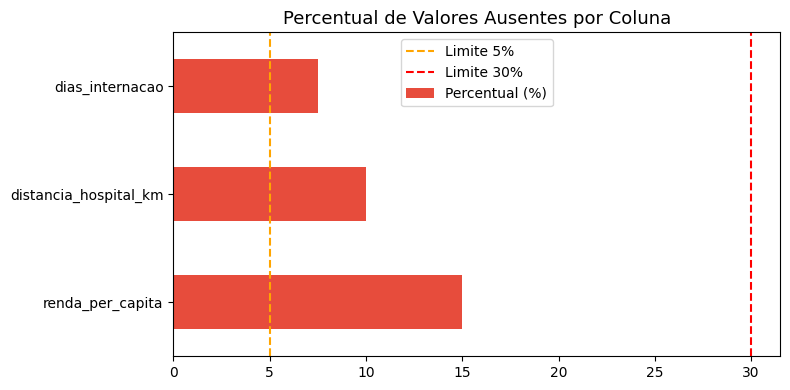

In [ ]:
ausentes = df.isnull().sum()
pct_ausentes = (ausentes / len(df) * 100).round(2)

resumo_ausentes = pd.DataFrame({
    'Ausentes': ausentes,
    'Percentual (%)': pct_ausentes
}).query('Ausentes > 0').sort_values('Percentual (%)', ascending=False)

print("COLUNAS COM VALORES AUSENTES:")
print(resumo_ausentes)

fig, ax = plt.subplots(figsize=(8, 4))
resumo_ausentes['Percentual (%)'].plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_title('Percentual de Valores Ausentes por Coluna', fontsize=13)
ax.axvline(5, color='orange', linestyle='--', label='Limite 5%')
ax.axvline(30, color='red', linestyle='--', label='Limite 30%')
ax.legend()
plt.tight_layout()
plt.show()

 ## 5. Tratamento de Assimetria (Skewness)
 Variáveis como "Renda" costumam ter **cauda longa** (muitas pessoas ganham pouco, poucas ganham muito).
 Aplicamos a transformação logarítmica para tornar a distribuição mais "normal", o que facilita o aprendizado de muitos algoritmos de ML.

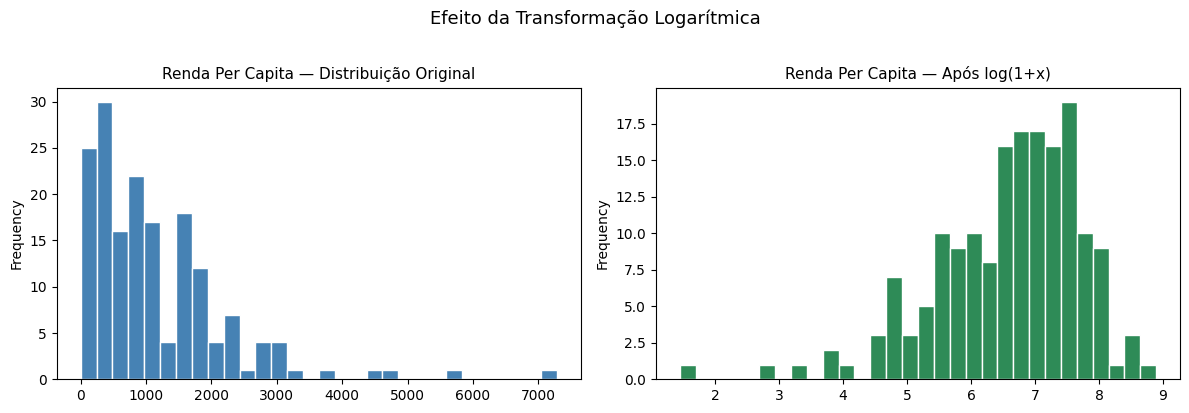

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['renda_per_capita'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Renda Per Capita — Distribuição Original', fontsize=11)

np.log1p(df['renda_per_capita'].dropna()).plot(kind='hist', bins=30, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Renda Per Capita — Após log(1+x)', fontsize=11)

plt.suptitle('Efeito da Transformação Logarítmica', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

 ## 6. Divisão Treino/Teste e Imputação
 **Atenção:** Primeiro dividimos os dados para evitar o *Data Leakage* (vazamento de dados).
 Calculamos a mediana apenas no conjunto de **treino** e usamos esse valor para preencher as lacunas tanto no treino quanto no teste.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['obito'])
y = df['obito']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cols_numericas = ['idade_paciente', 'renda_per_capita', 'distancia_hospital_km',
                  'internacoes_ano', 'dias_internacao']

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[cols_numericas])

X_train_imp = X_train.copy()
X_test_imp = X_test.copy()
X_train_imp[cols_numericas] = imputer.transform(X_train[cols_numericas])
X_test_imp[cols_numericas] = imputer.transform(X_test[cols_numericas])

print(f"Ausentes tratados no treino e teste.")
X_train_imp.info()
X_test_imp.info()

Ausentes tratados no treino e teste.
<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 79 to 102
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   municipio              160 non-null    object 
 1   regiao                 160 non-null    object 
 2   nivel_atencao          160 non-null    object 
 3   idade_paciente         160 non-null    float64
 4   renda_per_capita       160 non-null    float64
 5   distancia_hospital_km  160 non-null    float64
 6   internacoes_ano        160 non-null    float64
 7   dias_internacao        160 non-null    float64
dtypes: float64(5), object(3)
memory usage: 11.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 95 to 76
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   municipio              40 non-null     object 
 1   regiao                 40 non-n

 ## 7. Codificação de Variáveis Categóricas
 Modelos matemáticos não entendem palavras.
 * **OrdinalEncoder**: Usado para "Nível de Atenção" pois existe uma hierarquia (Básica < Média < Alta).
 * **OneHotEncoder**: Usado para "Região", criando colunas binárias para cada categoria nominal.

In [ ]:
# Ordinal para dados com hierarquia
ordem_atencao = [['Básica', 'Média Complexidade', 'Alta Complexidade']]
ord_enc = OrdinalEncoder(categories=ordem_atencao)
ord_enc.fit(X_train_imp[['nivel_atencao']])

X_train_imp['nivel_atencao_enc'] = ord_enc.transform(X_train_imp[['nivel_atencao']])
X_test_imp['nivel_atencao_enc'] = ord_enc.transform(X_test_imp[['nivel_atencao']])

# One-Hot para dados nominais
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train_imp[['regiao']])

ohe_treino = pd.DataFrame(ohe.transform(X_train_imp[['regiao']]), columns=ohe.get_feature_names_out(['regiao']), index=X_train_imp.index)
ohe_teste = pd.DataFrame(ohe.transform(X_test_imp[['regiao']]), columns=ohe.get_feature_names_out(['regiao']), index=X_test_imp.index)

X_train_imp = pd.concat([X_train_imp.drop(columns=['regiao']), ohe_treino], axis=1)
X_test_imp = pd.concat([X_test_imp.drop(columns=['regiao']), ohe_teste], axis=1)

print("Categorias convertidas em números.")
X_train_imp.head()

Categorias convertidas em números.


,municipio,nivel_atencao,idade_paciente,renda_per_capita,distancia_hospital_km,internacoes_ano,dias_internacao,nivel_atencao_enc,regiao_Leste,regiao_Sertão
79,União dos Palmares,Básica,57.192847,919.041381,54.434694,3.0,1.277955,0.0,1.0,0.0
197,União dos Palmares,Básica,51.771168,845.068874,26.642342,3.0,7.083394,0.0,1.0,0.0
38,Maceió,Alta Complexidade,57.653610,3131.738394,19.106718,2.0,1.000000,2.0,1.0,0.0
24,União dos Palmares,Básica,53.320392,179.348736,52.307484,0.0,1.000000,0.0,1.0,0.0
122,Arapiraca,Alta Complexidade,12.376762,2202.399535,30.419718,5.0,1.000000,2.0,1.0,0.0


 ## 8. Engenharia de Atributos (Feature Engineering)
 Criamos novas colunas a partir das existentes para dar mais "inteligência" ao modelo:
 1. **Internações por dia**: Uma taxa de frequência.
 2. **Log Renda**: Para estabilizar a variância.
 3. **Faixa Etária**: Discretização de uma variável contínua.

In [ ]:
X_train_imp['internacoes_por_dia'] = X_train_imp['internacoes_ano'] / X_train_imp['dias_internacao'].clip(lower=1)
X_test_imp['internacoes_por_dia'] = X_test_imp['internacoes_ano'] / X_test_imp['dias_internacao'].clip(lower=1)

X_train_imp['log_renda'] = np.log1p(X_train_imp['renda_per_capita'])
X_test_imp['log_renda'] = np.log1p(X_test_imp['renda_per_capita'])

bins = [0, 18, 40, 60, 100]
labels = ['jovem', 'adulto', 'meia_idade', 'idoso']
X_train_imp['faixa_etaria'] = pd.cut(X_train_imp['idade_paciente'], bins=bins, labels=labels)
X_test_imp['faixa_etaria'] = pd.cut(X_test_imp['idade_paciente'], bins=bins, labels=labels)

print("Novos atributos criados com sucesso.")
X_train_imp.head()

Novos atributos criados com sucesso.


,municipio,nivel_atencao,idade_paciente,renda_per_capita,distancia_hospital_km,internacoes_ano,dias_internacao,nivel_atencao_enc,regiao_Leste,regiao_Sertão,internacoes_por_dia,log_renda,faixa_etaria
79,União dos Palmares,Básica,57.192847,919.041381,54.434694,3.0,1.277955,0.0,1.0,0.0,2.347501,6.824419,meia_idade
197,União dos Palmares,Básica,51.771168,845.068874,26.642342,3.0,7.083394,0.0,1.0,0.0,0.423526,6.740601,meia_idade
38,Maceió,Alta Complexidade,57.653610,3131.738394,19.106718,2.0,1.000000,2.0,1.0,0.0,2.000000,8.049663,meia_idade
24,União dos Palmares,Básica,53.320392,179.348736,52.307484,0.0,1.000000,0.0,1.0,0.0,0.000000,5.194892,meia_idade
122,Arapiraca,Alta Complexidade,12.376762,2202.399535,30.419718,5.0,1.000000,2.0,1.0,0.0,5.000000,7.697757,jovem


 ## 9. Escalonamento de Variáveis (Scaling)
 Colocamos todas as variáveis numéricas na mesma escala (média 0 e desvio padrão 1).
 Isso impede que variáveis com números grandes (ex: Renda) dominem variáveis com números pequenos (ex: Internações) de forma injusta.

In [ ]:
cols_para_escalar = ['idade_paciente', 'log_renda', 'distancia_hospital_km',
                     'dias_internacao', 'internacoes_por_dia']

scaler = StandardScaler()
scaler.fit(X_train_imp[cols_para_escalar])

X_train_imp[cols_para_escalar] = scaler.transform(X_train_imp[cols_para_escalar])
X_test_imp[cols_para_escalar] = scaler.transform(X_test_imp[cols_para_escalar])

print("Dados escalonados (Média 0, Desvio Padrão 1).")
X_train_imp.describe().round(2)

Dados escalonados (Média 0, Desvio Padrão 1).


,idade_paciente,renda_per_capita,distancia_hospital_km,internacoes_ano,dias_internacao,nivel_atencao_enc,regiao_Leste,regiao_Sertão,internacoes_por_dia,log_renda
count,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00
mean,-0.00,1127.35,0.00,3.02,-0.00,0.92,0.42,0.26,0.00,-0.00
std,1.00,903.42,1.00,1.67,1.00,0.85,0.49,0.44,1.00,1.00
min,-2.61,3.26,-1.05,0.00,-0.80,0.00,0.00,0.00,-1.03,-4.90
25%,-0.70,560.43,-0.60,2.00,-0.75,0.00,0.00,0.00,-0.77,-0.29
50%,0.05,919.04,-0.26,3.00,-0.34,1.00,0.00,0.00,-0.36,0.17
75%,0.76,1524.33,0.26,4.00,0.44,2.00,1.00,1.00,0.48,0.65
max,2.09,5643.27,6.28,7.00,4.76,2.00,1.00,1.00,3.51,1.89
